<a href="https://colab.research.google.com/github/Malvocado/Machine_Learing_Final_Project/blob/main/Linear_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Load Data

In [17]:
df = pd.read_csv('BMW_sales_data_after_processing.csv')

In [18]:
print(df.shape)
df.head()

(50000, 11)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [19]:
df.columns.tolist()

['Model',
 'Year',
 'Region',
 'Color',
 'Fuel_Type',
 'Transmission',
 'Engine_Size_L',
 'Mileage_KM',
 'Price_USD',
 'Sales_Volume',
 'Sales_Classification']

#Data Visualizaton

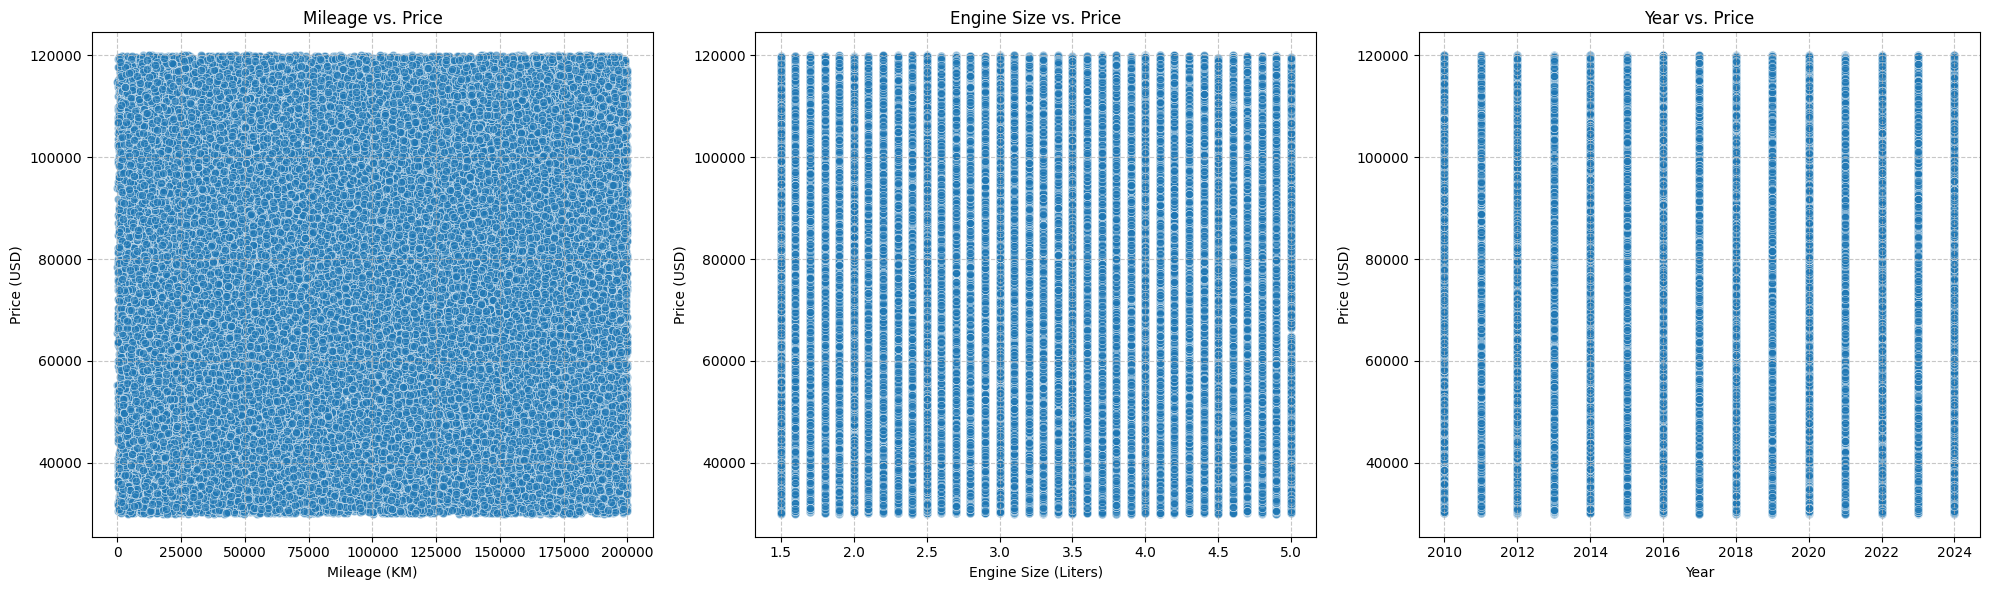

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

# Plot 1: Mileage_KM vs. Price_USD
sns.scatterplot(ax=axes[0], data=df, x='Mileage_KM', y='Price_USD', alpha=0.6)
axes[0].set_title('Mileage vs. Price')
axes[0].set_xlabel('Mileage (KM)')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Engine_Size_L vs. Price_USD
sns.scatterplot(ax=axes[1], data=df, x='Engine_Size_L', y='Price_USD', alpha=0.6)
axes[1].set_title('Engine Size vs. Price')
axes[1].set_xlabel('Engine Size (Liters)')
axes[1].set_ylabel('Price (USD)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Year vs. Price_USD
sns.scatterplot(ax=axes[2], data=df, x='Year', y='Price_USD', alpha=0.6)
axes[2].set_title('Year vs. Price')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Price (USD)')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Analysis of Individual Scatter Plots

These three scatter plots individually display the relationship between 'Price_USD' and 'Mileage_KM', 'Engine_Size_L', and 'Year', respectively.

*   **Mileage vs. Price:** Examine this plot for any visible trends. Typically, one might expect a negative correlation where higher mileage leads to lower prices. Observe if this pattern holds true or if the points are widely scattered.

*   **Engine Size vs. Price:** The previous scatter plot for engine size already showed a uniform distribution. This plot reaffirms that pattern. Look for any clusters or specific price ranges associated with certain engine sizes.

*   **Year vs. Price:** This plot shows how the car's price varies with its manufacturing year. As noted with the correlation matrix, the correlation was very low. This plot will visually confirm if there's any discernible trend (e.g., newer cars being more expensive) or if prices are largely independent of the year in this dataset.

#Correlattion Analysis

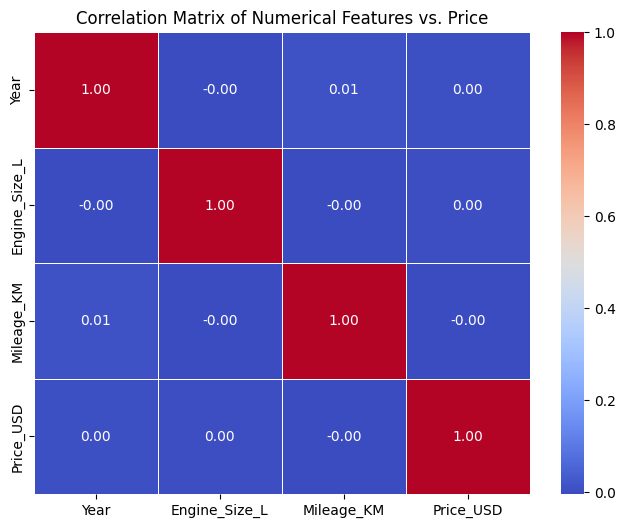

In [21]:
numerical_features = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features vs. Price')
plt.show()

#Separate Features and Target

In [22]:
X = df[['Model', 'Year', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Engine_Size_L', 'Mileage_KM']]
y = df['Price_USD']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (50000, 8)
Target (y) shape: (50000,)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131


,Price_USD
0,98740
1,79219
2,113265
3,60971
4,49898


##Split data into train and test data


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 8)
X_test shape: (10000, 8)
y_train shape: (40000,)
y_test shape: (10000,)


### Scaling Numerical Features

We will now apply `StandardScaler` to the numerical features in our training and testing datasets (`X_train` and `X_test`). This is an important preprocessing step that transforms the data such that it has a mean of 0 and a standard deviation of 1. This helps in improving the performance of many machine learning algorithms, especially those that are sensitive to the scale of the input features (e.g., linear regression, SVMs, neural networks).

In [25]:
# Identify numerical columns (excluding 'Year' if treated as categorical, but here we assume it's numerical for scaling)
numerical_cols = ['Year', 'Engine_Size_L', 'Mileage_KM']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train after scaling numerical features:")
display(X_train.head())

print("X_test after scaling numerical features:")
display(X_test.head())

X_train after scaling numerical features:


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM
39087,X6,0.224835,Middle East,Grey,Hybrid,Manual,-1.431900,-0.409216
30893,X5,1.382378,South America,Grey,Diesel,Automatic,0.151171,-0.109110
45278,M5,-1.627233,Middle East,Silver,Diesel,Manual,1.041648,1.140116
16398,X6,-0.238182,Middle East,White,Petrol,Automatic,-0.343539,0.745582
13653,X5,0.456344,Asia,Blue,Electric,Automatic,0.744822,-0.379034


X_test after scaling numerical features:


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM
33553,5 Series,1.613886,Middle East,Grey,Diesel,Manual,0.843764,0.332740
9427,X1,1.382378,Africa,Black,Petrol,Manual,0.447997,0.915541
199,3 Series,1.382378,Asia,Grey,Diesel,Manual,-0.838248,-0.711531
12447,i8,0.687852,Africa,White,Hybrid,Automatic,-0.937190,-0.436567
39489,X1,-0.238182,Asia,Red,Hybrid,Automatic,-0.145655,1.528557


### Visualizing Scaled Numerical Features

Now, let's visualize the distributions of the numerical features after applying `StandardScaler`. This will help us confirm that the data has been transformed to have a mean of approximately 0 and a standard deviation of approximately 1.

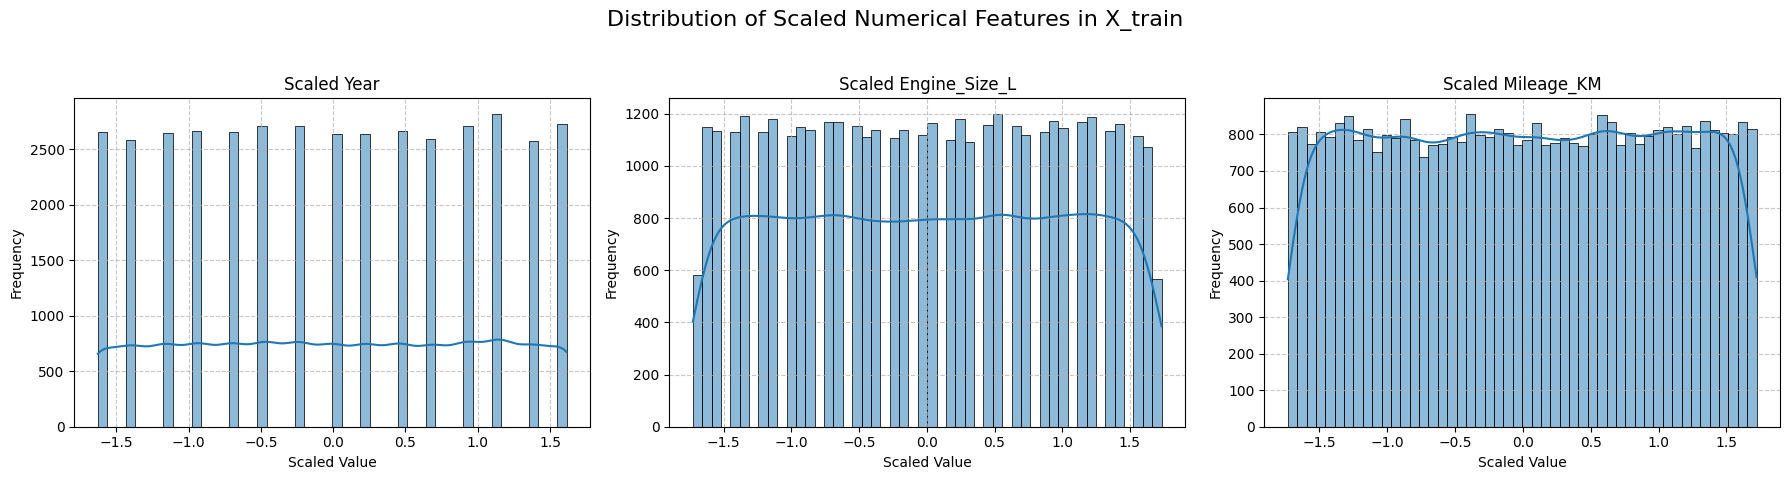

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(18, 5))
fig.suptitle('Distribution of Scaled Numerical Features in X_train', fontsize=16)

for i, col in enumerate(numerical_cols):
    sns.histplot(X_train[col], kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Scaled {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###Feature Encoding

### One-Hot Encoding Categorical Features

We will now use `OneHotEncoder` to convert our categorical features into a numerical format. This is necessary because most machine learning models cannot directly work with categorical data. One-hot encoding creates new binary columns for each unique category, indicating the presence (1) or absence (0) of that category. This helps prevent the model from assuming an ordinal relationship between categories where none exists.

In [27]:
# Identify categorical columns
categorical_cols = ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission']

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on X_train and transform both X_train and X_test
ohe.fit(X_train[categorical_cols])

X_train_encoded = ohe.transform(X_train[categorical_cols])
X_test_encoded = ohe.transform(X_test[categorical_cols])

# Create DataFrame with one-hot encoded features
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
X_train_ohe_df = pd.DataFrame(X_train_encoded, columns=ohe_feature_names, index=X_train.index)
X_test_ohe_df = pd.DataFrame(X_test_encoded, columns=ohe_feature_names, index=X_test.index)

# Drop original categorical columns and concatenate the one-hot encoded ones
X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

X_train = pd.concat([X_train, X_train_ohe_df], axis=1)
X_test = pd.concat([X_test, X_test_ohe_df], axis=1)

print("X_train after one-hot encoding:")
display(X_train.head())

print("X_test after one-hot encoding:")
display(X_test.head())

X_train after one-hot encoding:


,Year,Engine_Size_L,Mileage_KM,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
39087,0.224835,-1.431900,-0.409216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
30893,1.382378,0.151171,-0.109110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
45278,-1.627233,1.041648,1.140116,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
16398,-0.238182,-0.343539,0.745582,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
13653,0.456344,0.744822,-0.379034,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


X_test after one-hot encoding:


,Year,Engine_Size_L,Mileage_KM,Model_3 Series,Model_5 Series,Model_7 Series,Model_M3,Model_M5,Model_X1,Model_X3,...,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
33553,1.613886,0.843764,0.332740,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
9427,1.382378,0.447997,0.915541,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
199,1.382378,-0.838248,-0.711531,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
12447,0.687852,-0.937190,-0.436567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
39489,-0.238182,-0.145655,1.528557,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


#Create and trian model

In [29]:
# Create and train the model
model = LinearRegression()

# Fit the model to training data
model.fit(X_train, y_train)

print(" Model trained successfully!")

 Model trained successfully!


##Coefficients and interpret

In [32]:
model.intercept_

np.float64(75057.9196412928)

In [36]:
model.coef_

array([ 4.48956111e+01, -5.96425852e+01, -1.64279446e+02,  6.05535335e+02,
        3.88727016e+02,  7.43399189e+02, -7.14959784e+01, -5.65362582e+02,
        1.26113135e+02, -3.83856477e+02, -2.35455640e+02, -7.07033777e+02,
       -2.11386129e+01,  1.20568392e+02,  4.98375993e+00,  7.78397357e+02,
       -4.91393249e+01, -4.61346476e+02, -1.71080799e+02, -1.01814516e+02,
       -6.31122457e-01,  4.09925207e+02, -5.70464303e+02, -6.43637566e+01,
       -1.30980960e+02,  3.56514935e+02,  2.50735971e+01,  3.40396461e+02,
       -3.15068714e+02, -5.04013436e+01,  1.90322993e+02, -1.90322993e+02])

## Model Evaluation

In [33]:
# Make predictions on the training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate the model on the training set
r2_train = r2_score(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"Training Set R-squared: {r2_train:.4f}")
print(f"Training Set Mean Squared Error: {mse_train:.2f}")

# Evaluate the model on the test set
r2_test = r2_score(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTest Set R-squared: {r2_test:.4f}")
print(f"Test Set Mean Squared Error: {mse_test:.2f}")

Training Set R-squared: 0.0008
Training Set Mean Squared Error: 675067628.77

Test Set R-squared: -0.0012
Test Set Mean Squared Error: 677722367.78


### Actual vs. Predicted Values Plot

This plot visualizes how well the model's predictions align with the actual observed values. A good model will have points clustered closely around the diagonal line (where actual = predicted).

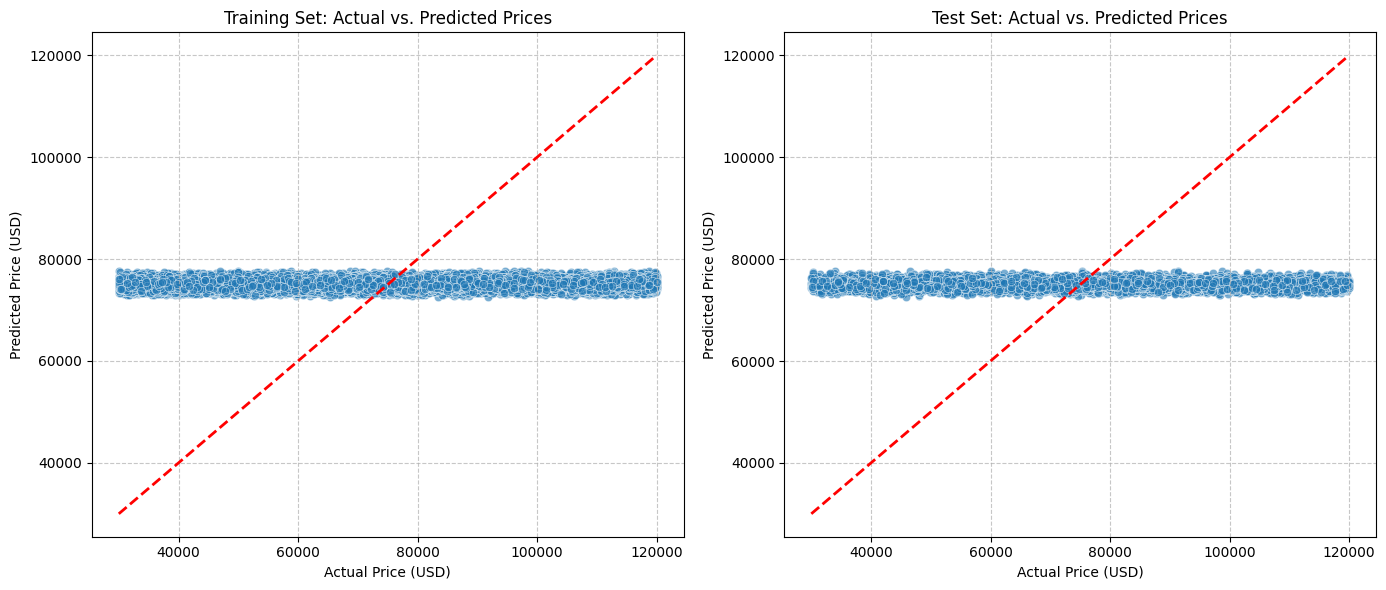

In [34]:
plt.figure(figsize=(14, 6))

# Plot for Training Set
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_train_pred, alpha=0.6)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.title('Training Set: Actual vs. Predicted Prices')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot for Test Set
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Test Set: Actual vs. Predicted Prices')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Residuals Plot

The residuals plot helps in checking the assumptions of a linear regression model. Ideally, residuals should be randomly scattered around zero, with no discernible pattern. A non-random pattern (e.g., a cone shape or a curve) indicates that the model might not be capturing the underlying relationship well.

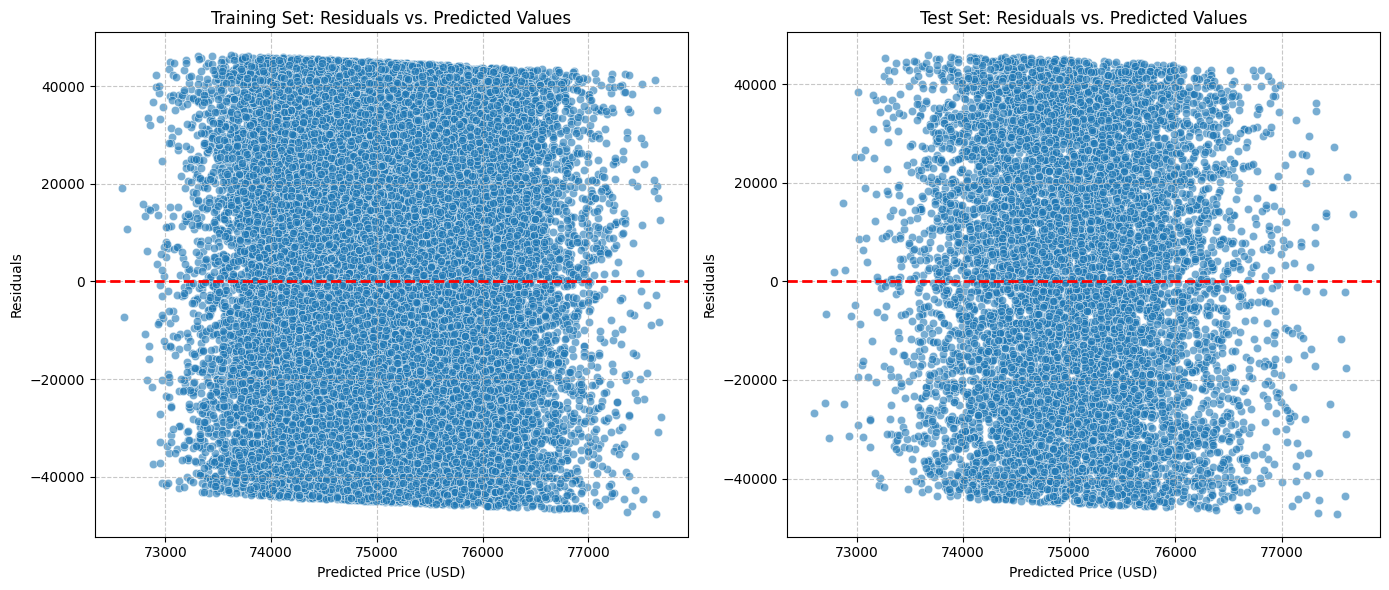

In [37]:
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

plt.figure(figsize=(14, 6))

# Residuals Plot for Training Set
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_pred, y=residuals_train, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Training Set: Residuals vs. Predicted Values')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Residuals Plot for Test Set
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_pred, y=residuals_test, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Test Set: Residuals vs. Predicted Values')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()